# A Non-Abelian Lattice Gauge Theory on a Qudit Processor
## $S_3$ gauge fields with matter, compiled onto trapped-ion qudits

**Companion to:** the reproduction of Ringbauer *et al.*, *A universal qudit quantum processor with
trapped ions* (Nat. Phys. **18**, 1053 (2022)) and the qudit-native $U(1)$ quantum link model built on
top of it.

---

### Why $S_3$

The $U(1)$ quantum link model in the companion notebook worked because the gauge group is **abelian**:
a single generator, a single ladder operator $U\sim S^+$, and a hopping term that split into commuting
two-level blocks. Non-abelian groups break all three properties, and the natural next target — $SU(3)$
— is far out of reach: its smallest non-trivial link truncation has dimension $1+3^2+3^2=19$, which
fused with matter pushes the local dimension past $150$.

$S_3$, the permutation group on three letters, is the smallest non-abelian group. It is a *finite*
gauge group, so its link Hilbert space is **exactly** $|G|=6$-dimensional with **no truncation of any
kind** — the Peter–Weyl theorem gives $\dim L^2(G)=\sum_j d_j^2 = 1+1+4=6$. That is precisely the qudit
dimension the hardware demonstrates natively.

This makes $S_3$ a good first non-abelian target: every genuinely non-abelian feature is present
(non-commuting gauge transformations, multi-dimensional irreps, flux that carries a *representation*
rather than a number, non-trivial fusion), while the numerics stay small enough to verify everything
exactly.

### What this notebook establishes

| | Result |
|---|---|
| **1** | The $S_3$ link is *exactly* a $d=6$ qudit — no truncation error anywhere in the model. |
| **2** | Gauss's law becomes a set of **non-commuting unitary constraints** $G_n(h)$, one per group element, rather than a set of Hermitian generators set to zero. Verified: $G_n(h)G_n(k)\neq G_n(k)G_n(h)$. |
| **3** | **The central compilation result.** The gauge-matter hopping term factorises exactly as $e^{-i\tau H_{\rm bond}} = W^\dagger\big(\mathbb 1\otimes e^{-i\tau h_{\rm free}}\big)W$, where $h_{\rm free}$ is the *gauge-field-independent* free-fermion hopping and $W$ is a two-qudit controlled gate. **All of the non-abelian physics is compiled into one controlled gate.** |
| **4** | $W$ decomposes into exactly **7 Mølmer–Sørensen gates** using the paper's own controlled-rotation primitive (Eq. S5), verified to machine precision. |
| **5** | Cost: $30$ MS gates per bond ($90$ per second-order Trotter step at $N=3$), against $12$ per bond for the abelian $U(1)$ model — going non-abelian costs a factor $\sim3$, not a factor of ten. |
| **6** | The link qudit needs $6$ logical $+1$ auxiliary $=7$ of the $8$ available $^{40}$Ca$^+$ levels. It fits, with one level to spare. |

Everything is verified numerically as the notebook proceeds. Where a result is *worse* than one might
hope, it is stated as such.

In [1]:
import numpy as np
import scipy.linalg as sla
import scipy.sparse as sp
import matplotlib.pyplot as plt
from itertools import permutations, product
from functools import reduce
import time

np.set_printoptions(precision=4, suppress=True, linewidth=130)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False})

def kronN(*ops):
    return reduce(np.kron, ops)

print('numpy', np.__version__)

numpy 2.4.4


---
# 1. The group $S_3$

$S_3$ is the group of permutations of three objects: order $6$, generated by a 3-cycle $r$ and a
transposition $s$ obeying $r^3=s^2=e$ and $srs=r^{-1}$. That last relation is the whole story — it
says $s$ and $r$ **do not commute**, which is what "non-abelian" means and what every difficulty in
this notebook traces back to.

Its three conjugacy classes are $\{e\}$, $\{r,r^2\}$ (the 3-cycles) and $\{s,sr,sr^2\}$ (the
transpositions), so it has three irreducible representations. The dimension theorem $\sum_j d_j^2=|G|$
forces $1+1+4=6$: the **trivial** rep, the **sign** rep, and a genuinely two-dimensional **standard**
rep. That two-dimensional irrep is what makes $S_3$ non-abelian — an abelian group has only
one-dimensional irreps.

The group is built by brute force from permutations, so nothing is assumed.

In [2]:
# --- the group, as permutations of (0,1,2) --------------------------------
ELTS = [p for p in permutations(range(3))]        # 6 tuples
def mul(p, q):
    return tuple(p[q[i]] for i in range(3))       # (pq)(i) = p(q(i))
def inv(p):
    o = [0]*3
    for i, v in enumerate(p): o[v] = i
    return tuple(o)

e = (0, 1, 2)
r = (1, 2, 0)                                     # 3-cycle
s = (1, 0, 2)                                     # transposition (diagonal in the u1,u2 basis)

# canonical ordering  g = s^a r^b  ->  index 3a + b.  This ordering is used
# everywhere below and is what makes the compilation of section 7 factorise.
G = []
for a in range(2):
    for b in range(3):
        g = e
        for _ in range(b): g = mul(r, g)
        if a: g = mul(s, g)
        G.append(g)
NG = len(G)
IDX = {g: i for i, g in enumerate(G)}
GNAME = ['e', 'r', 'r^2', 's', 's r', 's r^2']

MULT = np.array([[IDX[mul(G[i], G[j])] for j in range(NG)] for i in range(NG)])
print('multiplication table (row = left factor):')
print('      ' + ''.join(f'{n:>7}' for n in GNAME))
for i in range(NG):
    print(f'{GNAME[i]:>5} ' + ''.join(f'{GNAME[MULT[i,j]]:>7}' for j in range(NG)))

print('\nnon-abelian?  s r  =', GNAME[IDX[mul(s, r)]], '   r s  =', GNAME[IDX[mul(r, s)]],
      '  ->  s r != r s :', mul(s, r) != mul(r, s))
print('s r s = r^-1 ?', mul(mul(s, r), s) == inv(r))

# conjugacy classes
classes = []
for g in G:
    orb = frozenset(mul(mul(h, g), inv(h)) for h in G)
    if orb not in classes: classes.append(orb)
print('\nconjugacy classes:', [sorted(GNAME[IDX[x]] for x in c) for c in classes])

multiplication table (row = left factor):
            e      r    r^2      s    s r  s r^2
    e       e      r    r^2      s    s r  s r^2
    r       r    r^2      e  s r^2      s    s r
  r^2     r^2      e      r    s r  s r^2      s
    s       s    s r  s r^2      e      r    r^2
  s r     s r  s r^2      s    r^2      e      r
s r^2   s r^2      s    s r      r    r^2      e

non-abelian?  s r  = s r    r s  = s r^2   ->  s r != r s : True
s r s = r^-1 ? True

conjugacy classes: [['e'], ['r', 'r^2'], ['s', 's r', 's r^2']]


In [3]:
# --- the three irreducible representations ---------------------------------
def sgn(p):
    'parity of the permutation'
    return -1 if (p[0] > p[1]) ^ (p[1] > p[2]) ^ (p[0] > p[2]) else 1

# standard 2D irrep: act by permutation matrices on the plane orthogonal to (1,1,1)
u1 = np.array([1, -1, 0]) / np.sqrt(2)
u2 = np.array([1, 1, -2]) / np.sqrt(6)
B = np.vstack([u1, u2])                            # 2 x 3
def permmat(p):
    M = np.zeros((3, 3))
    for i in range(3): M[p[i], i] = 1
    return M
def D_std(p):
    return B @ permmat(p) @ B.T                    # real orthogonal 2x2

IRREPS = {'triv': (1, lambda p: np.array([[1.0]])),
          'sgn':  (1, lambda p: np.array([[float(sgn(p))]])),
          'std':  (2, D_std)}
JLIST = ['triv', 'sgn', 'std']

# --- checks ----------------------------------------------------------------
ok_hom, ok_orth = True, True
for name, (d, D) in IRREPS.items():
    for g in G:
        for h in G:
            ok_hom &= np.allclose(D(mul(g, h)), D(g) @ D(h))
    for g in G:
        ok_orth &= np.allclose(D(g) @ D(g).T, np.eye(d))
print('all three maps are group homomorphisms :', ok_hom)
print('all three are real orthogonal          :', ok_orth)

chars = {name: np.array([np.trace(D(g)) for g in G]) for name, (d, D) in IRREPS.items()}
print('\ncharacter table (columns = e | 3-cycles | transpositions):')
print(f"{'irrep':>6} {'dim':>4}   chi(e)  chi(r)  chi(s)")
for name in JLIST:
    d = IRREPS[name][0]
    print(f'{name:>6} {d:>4}   {chars[name][0]:+6.2f}  {chars[name][1]:+6.2f}  {chars[name][3]:+6.2f}')

Cmat = np.array([[np.vdot(chars[a], chars[b]) / NG for b in JLIST] for a in JLIST])
print('\ncharacter orthogonality  <chi_a, chi_b>/|G| = delta_ab :',
      np.allclose(Cmat, np.eye(3)))
print('dimension theorem  sum_j d_j^2 =', sum(IRREPS[j][0]**2 for j in JLIST), '= |G| =', NG)

all three maps are group homomorphisms : True
all three are real orthogonal          : True

character table (columns = e | 3-cycles | transpositions):
 irrep  dim   chi(e)  chi(r)  chi(s)
  triv    1    +1.00   +1.00   +1.00
   sgn    1    +1.00   +1.00   -1.00
   std    2    +2.00   -1.00   +0.00

character orthogonality  <chi_a, chi_b>/|G| = delta_ab : True
dimension theorem  sum_j d_j^2 = 6 = |G| = 6


### Reading the output

The multiplication table shows $sr\neq rs$ explicitly — this is a genuinely non-abelian group, not a
relabelled abelian one. The character table matches the textbook $S_3$ table, the characters are
orthonormal, and $\sum_j d_j^2 = 6 = |G|$.

That last identity is the one that matters for hardware. **Peter–Weyl** says the space of functions on
the group — which *is* the Hilbert space of a gauge link — decomposes as
$$L^2(G) \;\cong\; \bigoplus_j V_j \otimes V_j^*, \qquad \dim L^2(G) = \sum_j d_j^2 = 6 .$$
So an $S_3$ gauge link is **exactly** a six-level system. There is no truncation, no $j_{\max}$, no
convergence study — unlike every continuous-group formulation, where the link Hilbert space is
infinite-dimensional and every simulation carries a truncation error. For a first non-abelian
hardware demonstration this removes an entire axis of systematic uncertainty.

---
# 2. The link Hilbert space and its operators

A gauge link carries a group element $g\in G$: the parallel transporter. Its Hilbert space has the
**group-element basis** $\{|g\rangle\}_{g\in G}$, of dimension $6$.

Three families of operators act on it.

**Left and right translations** implement gauge transformations at the two ends of the link:
$$L_h|g\rangle = |hg\rangle, \qquad R_h|g\rangle = |gh\rangle .$$
These are the finite-group analogues of the left and right electric fields $E^a_L$, $E^a_R$. Two
points matter:

* $L$ is a representation of $G$: $L_hL_k = L_{hk}$ — so the $L_h$ *do not commute with each other*.
  This is the whole difference from $U(1)$, where the electric field is a single commuting number.
* $[L_h, R_k]=0$ for all $h,k$ — the two ends of a link transform independently.

**The parallel transporter itself**, $U^{\alpha\beta}$, is the matrix of the standard irrep evaluated
on the link variable:
$$U^{\alpha\beta}|g\rangle = D^{\alpha\beta}_{\rm std}(g)\,|g\rangle .$$
Note that it is **diagonal** in the group-element basis. This apparently innocuous fact is what makes
the whole compilation of §7 work, so it is worth flagging now.

The defining covariance relation, which is what makes $U$ a *parallel transporter* rather than an
arbitrary operator, is
$$L_h\,U^{\alpha\beta}\,L_h^\dagger \;=\; \sum_\gamma D^{\gamma\alpha}(h)\,U^{\gamma\beta},
\qquad R_h^\dagger\, U^{\alpha\beta}\, R_h \;=\; \sum_\gamma U^{\alpha\gamma} D^{\gamma\beta}(h).$$
All of this is checked numerically below.

In [4]:
DSTD = [D_std(g) for g in G]                      # 2x2 real orthogonal, indexed by group index

def Lop(h):
    'L_h |g> = |h g>'
    M = np.zeros((NG, NG), complex)
    ih = IDX[h]
    for j in range(NG): M[MULT[ih, j], j] = 1
    return M

def Rop(h):
    'R_h |g> = |g h>'
    M = np.zeros((NG, NG), complex)
    ih = IDX[h]
    for j in range(NG): M[MULT[j, ih], j] = 1
    return M

def Uop(a, b):
    'U^{ab} |g> = D^{ab}_std(g) |g>'
    return np.diag([DSTD[j][a, b] for j in range(NG)]).astype(complex)

# --- checks ----------------------------------------------------------------
hom  = all(np.allclose(Lop(mul(g, h)), Lop(g) @ Lop(h)) for g in G for h in G)
comm = all(np.allclose(Lop(g) @ Rop(h), Rop(h) @ Lop(g)) for g in G for h in G)
print('L is a representation of G      :', hom)
print('[L_h, R_k] = 0 for all h, k     :', comm)

nc = np.abs(Lop(s) @ Lop(r) - Lop(r) @ Lop(s)).max()
print(f'||[L_s, L_r]||  = {nc:.3f}   -> the electric-field operators DO NOT COMMUTE')
print('   (for U(1) the analogous commutator vanishes identically; this is the non-abelian core)')

cov = True
for h in G:
    Dh = D_std(h)
    for a in range(2):
        for b in range(2):
            lhs = Lop(h) @ Uop(a, b) @ Lop(h).conj().T
            rhs = sum(Dh[g_, a] * Uop(g_, b) for g_ in range(2))
            cov &= np.allclose(lhs, rhs)
            lhs2 = Rop(h).conj().T @ Uop(a, b) @ Rop(h)
            rhs2 = sum(Uop(a, g_) * Dh[g_, b] for g_ in range(2))
            cov &= np.allclose(lhs2, rhs2)
print('U transforms as a parallel transporter under L and R :', cov)
print('U is diagonal in the group basis                     :',
      all(np.allclose(Uop(a, b), np.diag(np.diag(Uop(a, b)))) for a in range(2) for b in range(2)))

L is a representation of G      : True
[L_h, R_k] = 0 for all h, k     : True
||[L_s, L_r]||  = 1.000   -> the electric-field operators DO NOT COMMUTE
   (for U(1) the analogous commutator vanishes identically; this is the non-abelian core)
U transforms as a parallel transporter under L and R : True
U is diagonal in the group basis                     : True


### The one number that separates abelian from non-abelian

$\|[L_s,L_r]\|=2$. For a $U(1)$ link the electric field is a single operator $E$ and all its functions
commute; here the six translations $L_h$ generate a non-abelian algebra. Everything downstream —
non-commuting Gauss constraints, flux labelled by a representation rather than an integer, and the
need for a *controlled* gate rather than a phase — follows from this single non-vanishing commutator.

The other verified fact, that $U^{\alpha\beta}$ is **diagonal** in $|g\rangle$, is the one that pays
off during compilation: the gauge field never has to be "rotated" during the hopping term; it only
ever acts as a *control*.

---
# 3. The electric Hamiltonian and the Peter–Weyl transform

For a continuous group the electric energy is the quadratic Casimir. For a finite group its role is
played by the **Laplacian on the Cayley graph**: taking a conjugacy class $C$ (here the three
transpositions, each its own inverse, so the operator is manifestly Hermitian),
$$\Delta \;=\; |C| \;-\; \sum_{k\in C} L_k ,\qquad H_E = \lambda_E\sum_{\rm links}\Delta .$$
Because $C$ is a full conjugacy class, $\sum_{k\in C}L_k$ commutes with every $L_h$ and every $R_h$ —
it is gauge invariant, as an electric energy must be. By Schur's lemma it is a multiple of the
identity inside each irrep block, so
$$\Delta_j \;=\; |C| - \frac{|C|\,\chi_j(C)}{d_j}\;\Longrightarrow\;
\Delta_{\rm triv}=0,\qquad \Delta_{\rm std}=3,\qquad \Delta_{\rm sgn}=6 .$$

**The electric field is diagonal in the irrep basis, not the group basis.** The change of basis is the
non-abelian Fourier transform (Peter–Weyl):
$$|j,m,n\rangle \;=\; \sqrt{\frac{d_j}{|G|}}\sum_{g\in G} D^j_{mn}(g)^{*}\,|g\rangle .$$
This is a $6\times6$ unitary — the $S_3$ analogue of the QFT — and on this hardware it is a **single
qudit gate**, compiled by Algorithm 1 of the paper. The structural consequence is worth noting: the
entire electric sector costs one single-qudit gate, a virtual $Z$, and its inverse.

In [5]:
# --- Peter-Weyl (non-abelian Fourier) transform ----------------------------
rows, labels, jofrow = [], [], []
for jn in JLIST:
    dj, D = IRREPS[jn]
    for m in range(dj):
        for n in range(dj):
            rows.append(np.sqrt(dj / NG) * np.array([np.conj(D(g)[m, n]) for g in G]))
            labels.append(f'{jn}|{m}{n}')
            jofrow.append(jn)
F = np.array(rows)                                  # F |g-basis> -> |irrep basis>
print('Peter-Weyl transform is unitary :', np.allclose(F @ F.conj().T, np.eye(NG)))
print('basis labels:', labels)

CLASS_T = [g for g in G if sgn(g) == -1]            # the three transpositions
Delta_group = len(CLASS_T) * np.eye(NG) - sum(Lop(k) for k in CLASS_T)
Delta_irrep = F @ Delta_group @ F.conj().T
print('\nDelta in the irrep basis is diagonal :',
      np.allclose(Delta_irrep, np.diag(np.diag(Delta_irrep))))
print('eigenvalues by irrep :',
      {jn: float(np.round(np.real(Delta_irrep[i, i]), 6)) for i, jn in enumerate(jofrow)})
print('gauge invariant?  [Delta, L_h] = 0 :',
      all(np.allclose(Delta_group @ Lop(h), Lop(h) @ Delta_group) for h in G),
      '   [Delta, R_h] = 0 :',
      all(np.allclose(Delta_group @ Rop(h), Rop(h) @ Delta_group) for h in G))

Peter-Weyl transform is unitary : True
basis labels: ['triv|00', 'sgn|00', 'std|00', 'std|01', 'std|10', 'std|11']

Delta in the irrep basis is diagonal : True
eigenvalues by irrep : {'triv': 0.0, 'sgn': 6.0, 'std': 3.0}
gauge invariant?  [Delta, L_h] = 0 : True    [Delta, R_h] = 0 : True


---
# 4. Matter: quarks in the two-dimensional irrep

Matter must carry a colour index, otherwise the gauge structure is invisible. The smallest non-trivial
choice for $S_3$ is the two-dimensional standard irrep, so each site hosts **two fermionic modes**
$c_{n,1}, c_{n,2}$ and a four-dimensional Fock space
$$|{\rm vac}\rangle,\qquad c^\dagger_1|{\rm vac}\rangle,\quad c^\dagger_2|{\rm vac}\rangle,
\qquad c^\dagger_1c^\dagger_2|{\rm vac}\rangle .$$

Under a gauge transformation $h$ at that site, $\Theta(h)c^\dagger_\alpha\Theta(h)^\dagger =
\sum_\beta c^\dagger_\beta D^{\beta\alpha}(h)$, so the Fock space decomposes as
$$\mathbb C^4 \;=\; \underbrace{\mathbf 1}_{\rm vac}\;\oplus\;\underbrace{\mathbf 2}_{\rm one\ quark}\;
\oplus\;\underbrace{\mathbf 1'}_{\rm two\ quarks},$$
i.e. trivial $\oplus$ standard $\oplus$ **sign**. The doubly-occupied state sits in the *sign*
representation, because $\Lambda^2(\mathbf 2) = \mathbf 1'$ for $S_3$ — a purely non-abelian feature
with no $U(1)$ counterpart, and one that produces visible physics in §8.

**Level ordering.** The four matter levels are ordered as
$$|0\rangle=c^\dagger_1|{\rm vac}\rangle,\quad |1\rangle=c^\dagger_2|{\rm vac}\rangle,\quad
|2\rangle=|{\rm vac}\rangle,\quad |3\rangle=c^\dagger_1c^\dagger_2|{\rm vac}\rangle .$$
This is not cosmetic. It puts the colour doublet on the *adjacent* pair $(0,1)$ and makes
$\Theta(s)=\mathrm{diag}(-1,1,1,-1)$, which is exactly a two-level rotation by $2\pi$ on the pair
$(0,3)$. Both facts collapse the compilation of §7 to seven MS gates; a naive ordering costs several
times more.

In [6]:
DM = 4                                              # matter site dimension
# level order:  0 = c1|vac>, 1 = c2|vac>, 2 = |vac>, 3 = c1 c2 |vac>
c1 = np.zeros((DM, DM), complex); c1[2, 0] = 1.0; c1[1, 3] = 1.0
c2 = np.zeros((DM, DM), complex); c2[2, 1] = 1.0; c2[0, 3] = -1.0
CL = [c1, c2]
PAR = np.diag([-1., -1., 1., 1.]).astype(complex)   # (-1)^N  on the site
NUM = np.diag([1., 1., 0., 2.]).astype(complex)     # quark number

# canonical anticommutators
ok = True
for a in range(2):
    for b in range(2):
        ok &= np.allclose(CL[a] @ CL[b].conj().T + CL[b].conj().T @ CL[a],
                          (1.0 if a == b else 0.0) * np.eye(DM))
        ok &= np.allclose(CL[a] @ CL[b] + CL[b] @ CL[a], 0)
print('canonical anticommutation relations on the site :', ok)

def Theta(h):
    'gauge rotation of the matter Fock space'
    D = D_std(h)
    M = np.zeros((DM, DM), complex)
    M[:2, :2] = D                                   # doublet  (levels 0,1)
    M[2, 2] = 1.0                                   # vacuum   (trivial)
    M[3, 3] = np.linalg.det(D)                      # two quarks (sign rep)
    return M

print('Theta is a representation :', all(np.allclose(Theta(mul(g, h)), Theta(g) @ Theta(h))
                                         for g in G for h in G))
print('Theta(s) =', np.real(np.diag(Theta(s))), ' -> diagonal, = R^(0,3)(2 pi)')
print('Theta(r) doublet block =\n', np.real(Theta(r)[:2, :2]))
ok2 = all(np.allclose(Theta(h) @ CL[a].conj().T @ Theta(h).conj().T,
                      sum(CL[b].conj().T * D_std(h)[b, a] for b in range(2)))
          for h in G for a in range(2))
print('Theta(h) c^dag_a Theta^dag = sum_b c^dag_b D_ba(h) :', ok2)

canonical anticommutation relations on the site : True
Theta is a representation : True
Theta(s) = [-1.  1.  1. -1.]  -> diagonal, = R^(0,3)(2 pi)
Theta(r) doublet block =
 [[-0.5   -0.866]
 [ 0.866 -0.5  ]]
Theta(h) c^dag_a Theta^dag = sum_b c^dag_b D_ba(h) : True


---
# 5. The full model, and Gauss's law without generators

On an open chain of $N$ matter sites and $N-1$ links,
$$H \;=\; \underbrace{-w\sum_n\sum_{\alpha\beta}\Big(c^\dagger_{n,\alpha}\,U^{\alpha\beta}_n\,
c_{n+1,\beta}+\text{h.c.}\Big)}_{H_{\rm hop}}
\;+\;\underbrace{m\sum_n \hat N_n}_{H_{\rm mass}}
\;+\;\underbrace{\lambda_E\sum_n \Delta_n}_{H_{\rm el}} .$$

There is no plaquette term — this is $1{+}1$ dimensions.

### Gauss's law is a group, not an algebra

For $U(1)$ the constraint was $G_n|\psi\rangle=0$ with $G_n$ Hermitian. A **finite** group has no Lie
algebra, so there are no generators to set to zero. Instead there is one *unitary* constraint per
group element:
$$G_n(h) \;=\; \Theta_n(h)\;L^{(n)}_h\;R^{(n-1)}_{h^{-1}},\qquad
\text{physical}\iff G_n(h)|\psi\rangle = |\psi\rangle\ \ \forall h\in G,\ \forall n .$$
These compose as the group does, $G_n(h)G_n(k)=G_n(hk)$, and therefore **do not commute with each
other**. The projector onto the physical space at site $n$ is the group average
$$P_n \;=\; \frac{1}{|G|}\sum_{h\in G}G_n(h),$$
and the gauge-invariant error monitor used in §8 is $1-\langle P_n\rangle$ — the direct analogue of
$\langle G_n^2\rangle$ in the abelian case, and just as free.

### Register layout

$$[\,m_0(d{=}4),\; \ell_0(d{=}7),\; m_1(4),\; \ell_1(7),\;\dots,\;m_{N-1}(4)\,]$$

Each link is a $d=6$ qudit plus **one auxiliary level** used for spectroscopic decoupling in the
controlled-rotation gadget (§6) — $7$ of the $8$ levels of $^{40}$Ca$^+$. The auxiliary level is never
populated by the ideal circuit, which provides a second free diagnostic: leakage.

In [7]:
DL = 7                     # link qudit: 6 logical group states + 1 auxiliary level
AUX = 6

def pad(M, keep_aux_identity):
    'embed a 6x6 link operator into the 7-level qudit'
    out = np.zeros((DL, DL), complex)
    out[:NG, :NG] = M
    if keep_aux_identity: out[AUX, AUX] = 1.0
    return out

class S3LGT:
    '''U(1)-free, genuinely non-abelian: S_3 gauge field + colour-doublet matter.'''

    def __init__(self, N, w=1.0, m=0.4, lam=0.6):
        self.N, self.w, self.m, self.lam = N, w, m, lam
        self.dims = [DM if k % 2 == 0 else DL for k in range(2 * N - 1)]
        self.D = int(np.prod(self.dims))
        self.msite = lambda n: 2 * n               # register index of matter site n
        self.lsite = lambda n: 2 * n + 1           # register index of link n
        self._build()

    def emb(self, op, site):
        'sparse embedding of a single-site operator (the register is far too large for dense)'
        mats = [sp.identity(d, format='csr', dtype=complex) for d in self.dims]
        mats[site] = sp.csr_matrix(np.asarray(op, dtype=complex))
        out = mats[0]
        for M in mats[1:]: out = sp.kron(out, M, format='csr')
        return out

    def bond_local(self, n):
        'H_bond on register sites (2n, 2n+1, 2n+2): matter x link x matter, dim 4*7*4'
        Il = np.eye(DL, dtype=complex)
        H = np.zeros((DM * DL * DM, DM * DL * DM), complex)
        for a in range(2):
            for b in range(2):
                term = kronN(CL[a].conj().T @ PAR, pad(Uop(a, b), False), CL[b])
                H += -self.w * (term + term.conj().T)
        return H

    def free_hop_local(self):
        'h_free = -w sum_a (c^dag_a P) (x) c_a + h.c.   on two matter sites, dim 16'
        H = np.zeros((DM * DM, DM * DM), complex)
        for a in range(2):
            t = kronN(CL[a].conj().T @ PAR, CL[a])
            H += -self.w * (t + t.conj().T)
        return H

    def _build(self):
        N = self.N
        self.Hhop = sp.csr_matrix((self.D, self.D), dtype=complex)
        for n in range(N - 1):
            Hb = sp.csr_matrix(self.bond_local(n))
            sa = self.msite(n)
            dl_ = int(np.prod(self.dims[:sa])) if sa > 0 else 1
            dr_ = int(np.prod(self.dims[sa + 3:])) if sa + 3 < len(self.dims) else 1
            blk = sp.kron(sp.identity(dl_, format='csr', dtype=complex), Hb, format='csr')
            self.Hhop = self.Hhop + sp.kron(blk, sp.identity(dr_, format='csr', dtype=complex),
                                            format='csr')
        # mass and electric
        self.Hmass = sum(self.m * self.emb(NUM, self.msite(n)) for n in range(N))
        self.Hel = sum(self.lam * self.emb(pad(Delta_group, False), self.lsite(n))
                       for n in range(N - 1))
        self.H = (self.Hhop + self.Hmass + self.Hel).tocsr()
        # Gauss operators
        self.Gauss = {}
        for n in range(N):
            for h in G:
                op = self.emb(Theta(h), self.msite(n))
                if n < N - 1: op = op @ self.emb(pad(Lop(h), True), self.lsite(n))
                if n > 0:     op = op @ self.emb(pad(Rop(inv(h)), True), self.lsite(n - 1))
                self.Gauss[(n, h)] = op
        self.Pn = [sum(self.Gauss[(n, h)] for h in G) / NG for n in range(N)]
        self.Nop = sum(self.emb(NUM, self.msite(n)) for n in range(N))

mod2 = S3LGT(N=2)
print(f'N=2 register dims {mod2.dims}  ->  D = {mod2.D}')
print('[H, G_n(h)] = 0 for every site and every group element :',
      max(abs(mod2.H @ mod2.Gauss[(n, h)] - mod2.Gauss[(n, h)] @ mod2.H).max()
          for n in range(2) for h in G) < 1e-10)
A, Bb = mod2.Gauss[(0, s)], mod2.Gauss[(0, r)]
print(f'||[G_0(s), G_0(r)]|| = {abs(A@Bb - Bb@A).max():.3f}'
      '   -> the Gauss constraints THEMSELVES do not commute')
print('G_n(h) G_n(k) = G_n(hk) :',
      all(abs(mod2.Gauss[(0, g)] @ mod2.Gauss[(0, h)] - mod2.Gauss[(0, mul(g, h))]).max() < 1e-10
          for g in G for h in G))
print('P_n is a projector :', abs((mod2.Pn[0] @ mod2.Pn[0] - mod2.Pn[0])).max() < 1e-10,
      '  and [P_0, P_1] = 0 :',
      abs(mod2.Pn[0] @ mod2.Pn[1] - mod2.Pn[1] @ mod2.Pn[0]).max() < 1e-10)

N=2 register dims [4, 7, 4]  ->  D = 112
[H, G_n(h)] = 0 for every site and every group element : True
||[G_0(s), G_0(r)]|| = 1.732   -> the Gauss constraints THEMSELVES do not commute
G_n(h) G_n(k) = G_n(hk) : True
P_n is a projector : True   and [P_0, P_1] = 0 : True


In [8]:
# --- the physical sector, found by projecting random vectors ---------------
def zero_aux(v, model):
    'kill any amplitude on the auxiliary link levels'
    T = v.reshape(model.dims).copy()
    for n in range(model.N - 1):
        idx = [slice(None)]*len(model.dims); idx[model.lsite(n)] = AUX
        T[tuple(idx)] = 0
    return T.reshape(-1)

def physical_basis(model, ntry=120, seed=0):
    rng = np.random.default_rng(seed)
    V = []
    for _ in range(ntry):
        v = rng.normal(size=model.D) + 1j*rng.normal(size=model.D)
        v = zero_aux(v, model)
        for Pn in model.Pn: v = Pn @ v
        for _ in range(2):
            for u in V: v = v - np.vdot(u, v)*u
        nv = np.linalg.norm(v)
        if nv > 1e-6: V.append(v/nv)
    return np.array(V).T if V else np.zeros((model.D, 0), complex)

def physical_report(model):
    'physical subspace, rotated to diagonalise the quark number inside it'
    Vp = physical_basis(model)
    if Vp.shape[1] == 0: return Vp, 0, np.zeros(0)
    Nred = Vp.conj().T @ (model.Nop @ Vp)
    w, S = np.linalg.eigh((Nred + Nred.conj().T)/2)
    return Vp @ S, Vp.shape[1], np.real(w)

for N in (2, 3):
    mm = S3LGT(N=N)
    _, dphys, nq = physical_report(mm)
    hist = {}
    for x in np.round(nq).astype(int): hist[x] = hist.get(x, 0) + 1
    print(f'N={N}:  D = {mm.D:>5}   physical dim = {dphys:>2}   '
          f'({100*dphys/mm.D:5.2f} %)   quark-number content = {dict(sorted(hist.items()))}')

N=2:  D =   112   physical dim =  3   ( 2.68 %)   quark-number content = {np.int64(0): 1, np.int64(2): 1, np.int64(4): 1}


N=3:  D =  3136   physical dim = 11   ( 0.35 %)   quark-number content = {np.int64(0): 1, np.int64(2): 3, np.int64(3): 1, np.int64(4): 6}


### Reading the output — three points worth pausing on

**1. The constraints do not commute.** $\|[G_0(s),G_0(r)]\|\neq0$, while both still commute with $H$.
In the abelian model, Gauss's law was a single conserved number per site; here it is a *group* acting
on the register, and the physical space is the subspace of trivial isotype. This is the precise sense
in which the simulation problem is harder.

**2. The physical sector is very small.** At $N=3$ it is a handful of states inside a
$3136$-dimensional register — an even smaller fraction than the $4\%$ found for the $U(1)$ model,
because the constraint is now six conditions per site instead of one. As in the abelian case, this is
what makes $1-\langle P_n\rangle$ such a sensitive error monitor: noise has an enormous unphysical
space to fall into.

**3. $N=2$ is too small to have dynamics; $N=3$ is not.** Gauge invariance on an open chain forces the
matter representation at each end to match the adjoining link's irrep, and at $N=2$ each quark-number
sector collapses to a single state, so nothing can evolve. At $N=3$ the two-quark sector is genuinely
multi-dimensional: the quarks can sit on sites $(0,1)$, $(1,2)$ or $(0,2)$, with the intervening links
carrying whichever irrep the Gauss law demands. **That manifold is the physics this notebook
simulates**, and the flux irrep changes as the quarks move — a phenomenon with no abelian analogue.

---
# 6. Hardware layer

This section is a condensed restatement of the toolkit validated in the companion notebook; the
physics is unchanged, so the operations are stated, verified, and used.

**Native gates.** A resonant two-level rotation $\hat R^{i,j}(\theta,\phi)=\exp(-i\tfrac\theta2
\sigma^{ij}_\phi)$ (Eq. 1), the Mølmer–Sørensen gate $\mathrm{MS}^{i,j}(\theta,\phi)$ (Eq. 2) in its
phase-compensated form $\widetilde{\mathrm{MS}}$ (Fig. S6), which acts as the identity outside the
addressed two-level block, and virtual $Z$ rotations, which are frame changes and cost nothing.

**Algorithm 1** compiles an arbitrary $\mathrm{SU}(d)$ into $d(d-1)/2$ Givens rotations plus a
diagonal, using the corrected phase convention derived in the companion notebook.

**Two primitives** carry all the entangling cost:

* `ctrl_rot` — a rotation on the target conditioned on **one level** of the control qudit, via
  spectroscopic decoupling into an auxiliary level (Eq. S5, Fig. S7). Cost: **1 MS gate**.
* `hop_block` — the exchange $\exp[-i\theta(|a_0b_1\rangle\langle a_1b_0|+\text{h.c.})]$ built from an
  $XX$ and a $YY$ compensated MS gate, whose sum cancels the unwanted $|00\rangle\!-\!|11\rangle$
  branch. Cost: **2 MS gates**.

In [9]:
def sigma_phi(d, i, j, phi):
    M = np.zeros((d, d), complex); M[i, j] = np.exp(-1j*phi); M[j, i] = np.exp(1j*phi); return M

def R(d, i, j, theta, phi):
    'native resonant rotation, Eq. (1)'
    M = np.eye(d, dtype=complex); c, sn = np.cos(theta/2), np.sin(theta/2)
    M[i, i] = c; M[j, j] = c
    M[i, j] = -1j*sn*np.exp(-1j*phi); M[j, i] = -1j*sn*np.exp(1j*phi)
    return M

def MS_ab(dA, dB, i, j, theta, phi):
    S = np.kron(sigma_phi(dA, i, j, phi), np.eye(dB, dtype=complex)) \
      + np.kron(np.eye(dA, dtype=complex), sigma_phi(dB, i, j, phi))
    w, V = np.linalg.eigh(S @ S)
    return (V * np.exp(-1j*theta/4*w)) @ V.conj().T

def MS_tilde(dA, dB, i, j, theta, phi):
    'phase-compensated MS (Fig. S6): exactly the identity outside the (i,j) block'
    cA = np.ones(dA, complex); cA[i] = cA[j] = np.exp(1j*theta/4)
    cB = np.ones(dB, complex); cB[i] = cB[j] = np.exp(1j*theta/4)
    return np.kron(np.diag(cA), np.diag(cB)) @ MS_ab(dA, dB, i, j, theta, phi)

def givens_decompose(U, tol=1e-12):
    'Algorithm 1: U = [prod of two-level rotations] @ diag(exp(i*phases))'
    U = np.asarray(U, complex); d = U.shape[0]; Ut = U.copy(); Ms = []
    for c in range(d - 1):
        for rr in range(d - 1, c, -1):
            a_r, a_rm = Ut[rr, c], Ut[rr - 1, c]
            if abs(a_r) < tol: continue
            th = 2*np.arctan2(abs(a_r), abs(a_rm))
            ph = np.angle(a_r) - np.angle(a_rm) - np.pi/2
            Ut = R(d, rr - 1, rr, th, ph) @ Ut
            Ms.append((rr - 1, rr, th, ph))
    phases = np.angle(np.diag(Ut))
    pulses = [(i, j, -th, ph) for (i, j, th, ph) in Ms[::-1]]
    return pulses, phases

def apply_pulses(d, pulses, phases=None):
    U = np.diag(np.exp(1j*phases)).astype(complex) if phases is not None else np.eye(d, dtype=complex)
    for (i, j, th, ph) in pulses: U = R(d, i, j, th, ph) @ U
    return U

rng = np.random.default_rng(3)
for d in (4, 6, 7):
    A = rng.normal(size=(d, d)) + 1j*rng.normal(size=(d, d))
    Q, _ = np.linalg.qr(A)
    p, ph = givens_decompose(Q)
    print(f'd={d}: Algorithm 1 exact = {np.allclose(apply_pulses(d, p, ph), Q)}'
          f'   Givens pulses = {len(p)} (bound {d*(d-1)//2}),  virtual Z = {d}')
pF, phF = givens_decompose(F)
print(f'\nPeter-Weyl transform F: {len(pF)} resonant pulses + {NG} virtual Z, exact = '
      f'{np.allclose(apply_pulses(NG, pF, phF), F)}')

d=4: Algorithm 1 exact = True   Givens pulses = 6 (bound 6),  virtual Z = 4
d=6: Algorithm 1 exact = True   Givens pulses = 15 (bound 15),  virtual Z = 6
d=7: Algorithm 1 exact = True   Givens pulses = 21 (bound 21),  virtual Z = 7

Peter-Weyl transform F: 12 resonant pulses + 6 virtual Z, exact = True


In [10]:
def relabel(d, mapping):
    'pi-pulses realising a level permutation'
    where = {l: l for l in range(d)}; at = {l: l for l in range(d)}; seq = []
    for src, dst in sorted(mapping.items(), key=lambda kv: kv[1]):
        p = where[src]
        if p == dst: continue
        other = at[dst]
        seq.append((min(p, dst), max(p, dst), np.pi, np.pi/2))
        where[src], where[other] = dst, p
        at[dst], at[p] = src, other
    return seq

def seqU(d, seq):
    U = np.eye(d, dtype=complex)
    for (i, j, th, ph) in seq: U = R(d, i, j, th, ph) @ U
    return U

def ctrl_rot(dC, dT, c, tgt, theta, phi, aux):
    'target rotation R^{tgt}(theta,phi) conditioned on control level c.  1 MS gate.'
    ops = []
    if c != 1: ops.append(('R', 0, min(c, 1), max(c, 1), np.pi, np.pi/2))
    ops.append(('R', 0, 0, aux, np.pi, np.pi/2))                 # park level 0 out of reach
    pre = relabel(dT, {tgt[0]: 0, tgt[1]: 1})
    V = seqU(dT, pre)
    # the relabelling pi-pulses carry level-dependent phases; conjugation turns
    # sigma_phi^(0,1) into sigma_{phi'}^(t0,t1), so pre-compensate phi here
    phi_u = phi + np.angle(V[1, tgt[1]]) - np.angle(V[0, tgt[0]])
    ops += [('R', 1, i, j, th, ph) for (i, j, th, ph) in pre]
    ops.append(('R', 0, 0, 1, np.pi/2, phi_u - np.pi/2))
    ops.append(('MS', 0, 1, theta, phi_u))
    ops.append(('R', 0, 0, 1, np.pi/2, phi_u + np.pi/2))
    ops += [('R', 1, i, j, -th, ph) for (i, j, th, ph) in pre[::-1]]
    ops.append(('R', 0, 0, aux, np.pi, -np.pi/2))
    if c != 1: ops.append(('R', 0, min(c, 1), max(c, 1), np.pi, -np.pi/2))
    return ops

def hop_block(dA, dB, pairA, pairB, theta):
    'exp(-i theta (|a0 b1><a1 b0| + h.c.)) from an XX and a YY compensated MS.  2 MS gates.'
    a0, a1 = pairA; b0, b1 = pairB
    pa, pb = relabel(dA, {a0: 0, a1: 1}), relabel(dB, {b0: 0, b1: 1})
    VA, VB = seqU(dA, pa), seqU(dB, pb)
    xi = np.angle(VA[0, a0]*VB[1, b1]*np.conj(VA[1, a1]*VB[0, b0]))
    ops  = [('R', 0, i, j, th, ph) for (i, j, th, ph) in pa]
    ops += [('R', 1, i, j, th, ph) for (i, j, th, ph) in pb]
    ops += [('Zv', 0, np.diag([np.exp(-1j*xi) if k == 1 else 1.0 for k in range(dA)]).astype(complex))]
    ops += [('MS', 0, 1, theta, 0.0), ('MS', 0, 1, theta, np.pi/2)]
    ops += [('Zv', 0, np.diag([np.exp(+1j*xi) if k == 1 else 1.0 for k in range(dA)]).astype(complex))]
    ops += [('R', 1, i, j, -th, ph) for (i, j, th, ph) in pb[::-1]]
    ops += [('R', 0, i, j, -th, ph) for (i, j, th, ph) in pa[::-1]]
    return ops

def pair_unitary(dA, dB, ops):
    U = np.eye(dA*dB, dtype=complex)
    for o in ops:
        if o[0] == 'R':
            _, sl, i, j, th, ph = o
            g = R(dA if sl == 0 else dB, i, j, th, ph)
            U = (np.kron(g, np.eye(dB, dtype=complex)) if sl == 0 else np.kron(np.eye(dA, dtype=complex), g)) @ U
        elif o[0] == 'Zv':
            _, sl, g = o
            U = (np.kron(g, np.eye(dB, dtype=complex)) if sl == 0 else np.kron(np.eye(dA, dtype=complex), g)) @ U
        else:
            _, i, j, th, ph = o
            U = MS_tilde(dA, dB, i, j, th, ph) @ U
    return U

nms = lambda ops: sum(1 for o in ops if o[0] == 'MS')

def logical(U, dC=None, dT=None):
    '''Restrict a (link x matter) operator to the LOGICAL control levels.
    The auxiliary level is scratch space: the gadget is correct provided it starts
    empty, which is exactly how the paper uses spectroscopic decoupling.'''
    dC = DL if dC is None else dC; dT = DM if dT is None else dT
    idx = [a*dT + b for a in range(NG) for b in range(dT)]
    return np.asarray(U)[np.ix_(idx, idx)]

# --- validate the two primitives -------------------------------------------
print('controlled rotation (control d=7 with aux level 6, target d=4):')
allok = True
for c in range(6):
    for tgt in [(0, 1), (0, 3), (1, 2)]:
        for th, ph in [(0.7, 0.3), (2*np.pi, 0.0), (np.pi, np.pi/2)]:
            ops = ctrl_rot(DL, DM, c, tgt, th, ph, AUX)
            U = pair_unitary(DL, DM, ops)
            Pc = np.zeros((DL, DL), complex); Pc[c, c] = 1
            V = np.kron(Pc, R(DM, tgt[0], tgt[1], th, ph)) \
              + np.kron(np.eye(DL, dtype=complex) - Pc, np.eye(DM, dtype=complex))
            ok = np.allclose(logical(U), logical(V), atol=1e-9); allok &= ok
print('   exact on the logical subspace, every control level / target pair / angle :', allok,
      f'   ({nms(ctrl_rot(DL, DM, 3, (0,3), 1.0, 0.0, AUX))} MS gate)')

print('\nhopping block (two matter qudits, d=4):')
ok2 = True
for pa in [(0, 2), (1, 2), (0, 3)]:
    for pb in [(2, 0), (2, 1), (3, 1)]:
        for th in (0.31, -0.62):
            ops = hop_block(DM, DM, pa, pb, th)
            U = pair_unitary(DM, DM, ops)
            Hb = np.zeros((DM*DM, DM*DM), complex)
            Hb[pa[0]*DM + pb[1], pa[1]*DM + pb[0]] = 1
            Hb[pa[1]*DM + pb[0], pa[0]*DM + pb[1]] = 1
            ok2 &= np.allclose(U, sla.expm(-1j*th*Hb), atol=1e-9)
print('   exact for every level pair and angle :', ok2,
      f'   ({nms(hop_block(DM, DM, (0,2), (2,0), 0.3))} MS gates)')

controlled rotation (control d=7 with aux level 6, target d=4):
   exact on the logical subspace, every control level / target pair / angle : True    (1 MS gate)

hopping block (two matter qudits, d=4):
   exact for every level pair and angle : True    (2 MS gates)


---
# 7. Compiling the non-abelian gauge coupling

## 7.1 The factorisation theorem

This is the technical heart of the notebook. The bond Hamiltonian can be written using the fact (§2)
that $U^{\alpha\beta}$ is **diagonal** in the group basis:
$$H_{\rm bond} \;=\; \sum_{g\in G}|g\rangle\langle g|\otimes h(g),\qquad
h(g) = -w\sum_{\alpha\beta}\Big(D^{\alpha\beta}(g)\,c^\dagger_{n,\alpha}c_{n+1,\beta}+\text{h.c.}\Big).$$

Applying the transformation law of the matter field — since $\Theta(g)^\dagger c_\beta \Theta(g) =
\sum_\gamma c_\gamma D^{\beta\gamma}(g)$ —
$$\boxed{\;h(g) \;=\; \Theta_{n+1}(g)^\dagger\; h_{\rm free}\; \Theta_{n+1}(g)\;}$$
where $h_{\rm free}=h(e)$ is the **ordinary, gauge-field-independent free-fermion hopping**. Therefore

$$\boxed{\;e^{-i\tau H_{\rm bond}} \;=\; W^\dagger\,\big(\mathbb 1_{\rm link}\otimes e^{-i\tau h_{\rm free}}\big)\,W,
\qquad W \;=\; \sum_{g\in G}|g\rangle\langle g|\otimes\Theta_{n+1}(g).\;}$$

The content of this is worth stating plainly. The gauge field never appears in the dynamical part of
the gate. **The entire non-abelian content of the coupling is compiled into a single two-qudit
controlled gate $W$**, and the hopping itself is the same free-fermion exchange one would need on an
ungauged chain. This is a cleaner structure than the abelian case, where the gauge field entered the
rotation angle of every block.

The reason is the fact flagged in §2: $U^{\alpha\beta}$ is diagonal in $|g\rangle$, so the link is only
ever a *control*, never a target. This is generic for finite gauge groups, and it is the main reason a
finite group is a good first non-abelian target for qudit hardware.

In [11]:
mod = S3LGT(N=3, w=1.0, m=0.4, lam=0.6)
Il, Im = np.eye(DL, dtype=complex), np.eye(DM, dtype=complex)

W = np.zeros((DL*DM, DL*DM), complex)
for ig, g in enumerate(G):
    Pg = np.zeros((DL, DL), complex); Pg[ig, ig] = 1
    W += np.kron(Pg, Theta(g))
Pa = np.zeros((DL, DL), complex); Pa[AUX, AUX] = 1
W += np.kron(Pa, Im)                                     # identity on the auxiliary level
print('W is unitary :', np.allclose(W @ W.conj().T, np.eye(DL*DM)))

hfree = mod.free_hop_local()
Hb = mod.bond_local(0)

# (i) the operator identity  h(g) = Theta(g)^dag h_free Theta(g)
Hb6 = Hb.reshape(DM, DL, DM, DM, DL, DM)
worst = 0.0
for ig, g in enumerate(G):
    hg = Hb6[:, ig, :, :, ig, :].reshape(DM*DM, DM*DM)      # the |g><g| block of H_bond
    conj = np.kron(np.eye(DM, dtype=complex), Theta(g)).conj().T @ hfree \
           @ np.kron(np.eye(DM, dtype=complex), Theta(g))
    worst = max(worst, np.abs(hg - conj).max())
print(f'h(g) = Theta(g)^dag h_free Theta(g)  for all six group elements : '
      f'max deviation {worst:.2e}')
assert worst < 1e-10

# (ii) the exponentiated statement, on the logical link levels
#      (the auxiliary level is scratch space and carries no gauge field)
KEEP = [a*DL*DM + e*DM + b for a in range(DM) for e in range(NG) for b in range(DM)]
Wfull = np.kron(np.eye(DM, dtype=complex), W)
for tau in (0.17, 0.5, 1.1, 2.7):
    Xmid = sla.expm(-1j*tau*hfree).reshape(DM, DM, DM, DM)   # (m_n, m_n+1, m_n', m_n+1')
    Xfull = np.einsum('abcd,ef->aebcfd', Xmid, np.eye(DL, dtype=complex)
                      ).reshape(DM*DL*DM, DM*DL*DM)
    lhs = (Wfull.conj().T @ Xfull @ Wfull)[np.ix_(KEEP, KEEP)]
    dev = np.abs(lhs - sla.expm(-1j*tau*Hb)[np.ix_(KEEP, KEEP)]).max()
    print(f'tau={tau:4.2f}:  W^dag (1 (x) e^(-i tau h_free)) W  vs  e^(-i tau H_bond)  '
          f'->  max deviation {dev:.2e}')
    assert dev < 1e-10
print('\n[OK] the factorisation is exact at every tau, and h_free carries no gauge field:')
print('     it is literally the free-fermion hopping of an UNGAUGED two-site chain.')

W is unitary : True
h(g) = Theta(g)^dag h_free Theta(g)  for all six group elements : max deviation 4.44e-16
tau=0.17:  W^dag (1 (x) e^(-i tau h_free)) W  vs  e^(-i tau H_bond)  ->  max deviation 4.44e-16
tau=0.50:  W^dag (1 (x) e^(-i tau h_free)) W  vs  e^(-i tau H_bond)  ->  max deviation 5.55e-16


tau=1.10:  W^dag (1 (x) e^(-i tau h_free)) W  vs  e^(-i tau H_bond)  ->  max deviation 5.55e-16
tau=2.70:  W^dag (1 (x) e^(-i tau h_free)) W  vs  e^(-i tau H_bond)  ->  max deviation 7.77e-16

[OK] the factorisation is exact at every tau, and h_free carries no gauge field:
     it is literally the free-fermion hopping of an UNGAUGED two-site chain.


## 7.2 Decomposing $W$ into seven MS gates

$W=\sum_g|g\rangle\langle g|\otimes\Theta(g)$ is a two-qudit gate between a $d=7$ link and a $d=4$
matter site. Compiled naively — six controlled $\mathrm{SU}(4)$'s — it would cost of order $75$ MS
gates. The group structure does far better.

Order the link levels as $g=s^ar^b\mapsto 3a+b$ (§1). Because $\Theta$ is a representation,
$\Theta(s^ar^b)=\Theta(s)^a\Theta(r)^b$, so
$$W \;=\; \underbrace{\Big[\textstyle\sum_{a,b}|ab\rangle\langle ab|\otimes\Theta(s)^a\Big]}_{W_s}\;
\underbrace{\Big[\textstyle\sum_{a,b}|ab\rangle\langle ab|\otimes\Theta(r)^b\Big]}_{W_r}$$
(in that order — the two factors do **not** commute, which is the non-abelian structure showing up
again in the compiler).

With the level ordering chosen in §4:

* $\Theta(r)^b$ is a **plane rotation on the adjacent pair $(0,1)$** — one controlled rotation per link
  level with $b\neq0$, i.e. $4$ levels $\Rightarrow$ **4 MS gates**.
* $\Theta(s)=\mathrm{diag}(-1,1,1,-1) = \hat R^{0,3}(2\pi)$ — a $2\pi$ rotation is $-\mathbb 1$ on the
  addressed pair regardless of phase, so it is one controlled rotation per link level with $a=1$, i.e.
  $3$ levels $\Rightarrow$ **3 MS gates**.

Total: **7 MS gates**, exactly.

In [12]:
# angle of the doublet rotation Theta(r)^b, solved from the matrix itself
def theta_r(b):
    M = np.linalg.matrix_power(np.real(Theta(r))[:2, :2], b)
    ang = np.arctan2(M[1, 0], M[0, 0])
    return 2*ang                                    # R(d,0,1,theta,pi/2) rotates by theta/2

for b in (1, 2):
    assert np.allclose(R(DM, 0, 1, theta_r(b), np.pi/2)[:2, :2],
                       np.linalg.matrix_power(Theta(r), b)[:2, :2]), b
print('doublet rotation angles :', [f'{theta_r(b):+.4f}' for b in (1, 2)], '(rad)')

def W_ops():
    'native op list for W on (link slot 0, matter slot 1)'
    ops = []
    for ig in range(NG):                            # W_r first
        a, b = divmod(ig, 3)
        if b: ops += ctrl_rot(DL, DM, ig, (0, 1), theta_r(b), np.pi/2, AUX)
    for ig in range(NG):                            # then W_s
        a, b = divmod(ig, 3)
        if a: ops += ctrl_rot(DL, DM, ig, (0, 3), 2*np.pi, 0.0, AUX)
    return ops

ops_W = W_ops()
UW = pair_unitary(DL, DM, ops_W)
print(f'compiled W  ==  W  (logical subspace) :  '
      f'{np.allclose(logical(UW), logical(W), atol=1e-9)}   '
      f'(max deviation {np.abs(logical(UW)-logical(W)).max():.2e})')
print(f'cost of W   :  {nms(ops_W)} MS gates,  {sum(1 for o in ops_W if o[0]=="R")} resonant pulses')

doublet rotation angles : ['+4.1888', '-4.1888'] (rad)
compiled W  ==  W  (logical subspace) :  True   (max deviation 8.86e-16)
cost of W   :  7 MS gates,  46 resonant pulses


In [13]:
# --- the free hopping: eight two-level blocks, exact ------------------------
def hfree_blocks(tau, w=1.0):
    'exp(-i tau h_free) as commuting two-level exchanges on two d=4 matter qudits'
    ops, blocks = [], []
    for a in range(2):
        t = kronN(CL[a].conj().T @ PAR, CL[a])
        Ha = -w*(t + t.conj().T)
        seen = set()
        for I in range(DM*DM):
            for J in range(I+1, DM*DM):
                amp = Ha[J, I]
                if abs(amp) > 1e-12 and (I, J) not in seen:
                    seen.add((I, J)); blocks.append((I, J, np.real(amp)))
    for (I, J, amp) in blocks:
        i0, i1 = divmod(I, DM); j0, j1 = divmod(J, DM)
        ops += hop_block(DM, DM, (i0, j0), (j1, i1), tau*amp)
    return ops, blocks

ops_h, blks = hfree_blocks(0.3)
print(f'h_free decomposes into {len(blks)} two-level blocks (4 per colour)')
print(f'compiled exp(-i tau h_free) exact : '
      f'{np.allclose(pair_unitary(DM, DM, ops_h), sla.expm(-1j*0.3*hfree), atol=1e-9)}'
      f'   ({nms(ops_h)} MS gates)')
print(f'\ntotal per bond : 2 x W ({2*nms(ops_W)} MS) + free hopping ({nms(ops_h)} MS) '
      f'= {2*nms(ops_W)+nms(ops_h)} MS gates')

h_free decomposes into 8 two-level blocks (4 per colour)


compiled exp(-i tau h_free) exact : True   (16 MS gates)

total per bond : 2 x W (14 MS) + free hopping (16 MS) = 30 MS gates


In [14]:
# ============================================================================
#  Trotter compilation on the full register
# ============================================================================
def shift(ops, slots):
    'relabel the two-slot op list onto register sites'
    out = []
    for o in ops:
        if o[0] == 'R':   out.append(('R', slots[o[1]], o[2], o[3], o[4], o[5]))
        elif o[0] == 'Zv': out.append(('U1', slots[o[1]], o[2]))
        else:              out.append(('MS', slots[0], slots[1], o[1], o[2], o[3], o[4]))
    return out

def diag_ops(model, tau):
    'mass (matter) and electric (link) terms: single-qudit, diagonal, virtual'
    ops = []
    for n in range(model.N):
        ops.append(('U1', model.msite(n), np.diag(np.exp(-1j*tau*model.m*np.diag(NUM)))))
    dE = np.real(np.diag(Delta_irrep))
    Dg = F.conj().T @ np.diag(np.exp(-1j*tau*model.lam*dE)) @ F
    for n in range(model.N - 1):
        ops.append(('U1', model.lsite(n), pad(Dg, True)))
    return ops

def bond_ops(model, n, tau):
    sm0, sl, sm1 = model.msite(n), model.lsite(n), model.msite(n+1)
    o  = shift(W_ops(), [sl, sm1])
    o += shift(hfree_blocks(tau, model.w)[0], [sm0, sm1])
    o += shift(inverse_ops(W_ops()), [sl, sm1])
    return o

def inverse_ops(ops):
    out = []
    for o in reversed(ops):
        if o[0] == 'R':   out.append(('R', o[1], o[2], o[3], -o[4], o[5]))
        elif o[0] == 'Zv': out.append(('Zv', o[1], o[2].conj().T))
        else:              out.append(('MS', o[1], o[2], -o[3], o[4]))
    return out

def trotter_ops(model, tau):
    'second-order symmetric Trotter step'
    nb = model.N - 1
    ops = diag_ops(model, tau/2)
    for b in range(nb - 1): ops += bond_ops(model, b, tau/2)
    ops += bond_ops(model, nb - 1, tau)
    for b in range(nb - 2, -1, -1): ops += bond_ops(model, b, tau/2)
    ops += diag_ops(model, tau/2)
    return ops

def count(ops):
    return dict(MS=sum(1 for o in ops if o[0] == 'MS'),
                R=sum(1 for o in ops if o[0] == 'R'),
                virtualZ=sum(1 for o in ops if o[0] == 'U1'))

# --- statevector engine -----------------------------------------------------
def apply_site(psi, U, site, dims):
    T = psi.reshape(dims)
    T = np.tensordot(U, T, axes=(1, site))
    return np.moveaxis(T, 0, site).reshape(-1)

def apply_pair(psi, U, sa, sb, dims):
    T = psi.reshape(dims)
    U4 = U.reshape(dims[sa], dims[sb], dims[sa], dims[sb])
    T = np.tensordot(U4, T, axes=([2, 3], [sa, sb]))
    return np.moveaxis(T, [0, 1], [sa, sb]).reshape(-1)

def run_ops(psi, ops, dims, noise=None, rng=None):
    for o in ops:
        if o[0] == 'U1':
            psi = apply_site(psi, o[2], o[1], dims)
        elif o[0] == 'R':
            _, sq, i, j, th, ph = o
            psi = apply_site(psi, R(dims[sq], i, j, th, ph), sq, dims)
            if noise: psi = noise(psi, [sq], 'R', rng)
        else:
            _, sa, sb, i, j, th, ph = o
            psi = apply_pair(psi, MS_tilde(dims[sa], dims[sb], i, j, th, ph), sa, sb, dims)
            if noise: psi = noise(psi, [sa, sb], 'MS', rng)
    return psi

dims = mod.dims
print('register dims', dims, ' D =', mod.D)
c1_ = count(trotter_ops(mod, 0.2))
print('gate count per second-order Trotter step (N=3):', c1_)

register dims [4, 7, 4, 7, 4]  D = 3136
gate count per second-order Trotter step (N=3): {'MS': 90, 'R': 420, 'virtualZ': 58}


In [15]:
# --- validate the compiled circuit against a reference Trotter step ---------
def reference_step(psi, model, tau):
    nb = model.N - 1
    def apply_diag(v, t):
        for o in diag_ops(model, t): v = apply_site(v, o[2], o[1], model.dims)
        return v
    def apply_bond(v, n, t):
        sm0 = model.msite(n)
        Ub = sla.expm(-1j*t*model.bond_local(n))
        T = v.reshape(model.dims)
        U6 = Ub.reshape(DM, DL, DM, DM, DL, DM)
        T = np.tensordot(U6, T, axes=([3, 4, 5], [sm0, sm0+1, sm0+2]))
        return np.moveaxis(T, [0, 1, 2], [sm0, sm0+1, sm0+2]).reshape(-1)
    v = apply_diag(psi, tau/2)
    for b in range(nb - 1): v = apply_bond(v, b, tau/2)
    v = apply_bond(v, nb - 1, tau)
    for b in range(nb - 2, -1, -1): v = apply_bond(v, b, tau/2)
    return apply_diag(v, tau/2)

rng = np.random.default_rng(5)
v0 = rng.normal(size=mod.D) + 1j*rng.normal(size=mod.D)
v0 = zero_aux(v0, mod); v0 /= np.linalg.norm(v0)     # auxiliary levels start empty
tau = 0.25
a = run_ops(v0.copy(), trotter_ops(mod, tau), dims)
b = reference_step(v0.copy(), mod, tau)
print(f'compiled native circuit  vs  reference Trotter step :  max deviation '
      f'{np.abs(a-b).max():.2e}')
print(f'norm preserved : {abs(np.linalg.norm(a)-1):.2e}')

compiled native circuit  vs  reference Trotter step :  max deviation 3.53e-16
norm preserved : 4.44e-15


### Reading the output

The full pulse-level circuit — resonant rotations, phase-compensated MS gates and virtual $Z$'s, with
every angle traced back to a matrix element of the $S_3$ Hamiltonian — reproduces the reference
second-order Trotter step to machine precision. Simultaneously verified: the factorisation theorem,
the seven-MS decomposition of $W$, the eight free-hopping blocks, the Peter–Weyl compilation of the
electric term, and all the phase bookkeeping in the level relabellings.

Two structural points follow.

**The electric sector is nearly free.** $H_{\rm mass}$ is diagonal in the matter basis and
$H_{\rm el}$ is diagonal in the *irrep* basis, so both are virtual $Z$ gates, the latter sandwiched
between one Peter–Weyl transform and its inverse. **No entangling gate is spent on the gauge field's
own energy** — every MS gate in the circuit goes into the gauge–matter coupling.

**All the entangling cost is $W$ and the free hop**, at $14+16=30$ MS gates per bond per Trotter step.

---
# 8. Dynamics: watching non-abelian flux change representation

## 8.1 The state and the observables

The dynamics run in the **two-quark sector** at $N=3$, which §5 showed to be three-dimensional. The
physical configurations are: quarks on sites $(0,1)$, on $(1,2)$, or on $(0,2)$ — and Gauss's law
forces the intervening links into whichever irrep makes the configuration a colour singlet. As the
quarks hop, the flux on each link must change its **representation**, not merely its magnitude.

The initial state is a gauge-invariant state built by projecting a simple product state onto the
physical sector. The tracked observables are:

| observable | what it tests |
|---|---|
| quark number on each site | the physics (do the quarks move as they should?) |
| link irrep populations $P(\text{triv}),P(\text{std}),P(\text{sgn})$ | **the non-abelian flux** — no $U(1)$ analogue |
| $1-\langle P_n\rangle$ | Gauss-law violation: a reference-free hardware error monitor |
| population of the auxiliary level | leakage out of the encoded space |
| $\langle H_{\rm el}\rangle$ | electric energy |

In [16]:
# --- build a physical two-quark initial state ------------------------------
Vphys, dphys, nq = physical_report(mod)
sel = Vphys[:, np.abs(nq - 2) < 1e-6]
# re-orthonormalise inside the fixed-quark-number block
sel, _ = np.linalg.qr(sel)
print(f'N=3 physical dimension {dphys};  two-quark sector: dimension {sel.shape[1]}')

# pick the state with the most weight on site 0
n0 = mod.emb(NUM, mod.msite(0))
proj = sel.conj().T @ (n0 @ sel)
ww, vv = np.linalg.eigh((proj + proj.conj().T)/2)
psi0 = sel @ vv[:, -1]
psi0 = psi0 / np.linalg.norm(psi0)
print('initial state is exactly physical :',
      all(abs(np.vdot(psi0, mod.Pn[n] @ psi0) - 1) < 1e-10 for n in range(mod.N)))
print('initial quark number :', f'{np.real(np.vdot(psi0, mod.Nop @ psi0)):.4f}')

# --- observables -----------------------------------------------------------
site_n = [mod.emb(NUM, mod.msite(n)) for n in range(mod.N)]
Pirrep = {}
for jn in JLIST:
    proj6 = F.conj().T @ np.diag([1.0 if jofrow[k] == jn else 0.0 for k in range(NG)]) @ F
    Pirrep[jn] = mod.emb(pad(proj6, False), mod.lsite(0))
Paux = sum(mod.emb(np.diag([0.]*AUX + [1.]), mod.lsite(n)) for n in range(mod.N-1))
Hel_op = mod.Hel

def measure(psi):
    d = dict(N0=np.real(np.vdot(psi, site_n[0] @ psi)),
             N1=np.real(np.vdot(psi, site_n[1] @ psi)),
             N2=np.real(np.vdot(psi, site_n[2] @ psi)),
             gauss=np.real(mod.N - sum(np.vdot(psi, mod.Pn[n] @ psi) for n in range(mod.N))),
             aux=np.real(np.vdot(psi, Paux @ psi)),
             Eel=np.real(np.vdot(psi, Hel_op @ psi)))
    for jn in JLIST: d['P_' + jn] = np.real(np.vdot(psi, Pirrep[jn] @ psi))
    return d
print('\ninitial link-0 irrep content :',
      {jn: round(measure(psi0)['P_' + jn], 4) for jn in JLIST})

N=3 physical dimension 11;  two-quark sector: dimension 3
initial state is exactly physical : True
initial quark number : 2.0000

initial link-0 irrep content : {'triv': np.float64(0.0), 'sgn': np.float64(0.0), 'std': np.float64(1.0)}


In [17]:
# --- noise model, calibrated from the companion notebook -------------------
R_PULSE, EPS_MS = 2.0e-4, 2.4e-2          # per resonant pulse / per fully entangling MS(pi)

def weyl(d, a, b):
    X = np.roll(np.eye(d, dtype=complex), 1, axis=0)
    Z = np.diag(np.exp(2j*np.pi*np.arange(d)/d))
    return np.linalg.matrix_power(X, a) @ np.linalg.matrix_power(Z, b)

def make_noise(dims, scale=1.0):
    'depolarizing noise, unravelled as random Weyl errors (exact in the ensemble average)'
    def noise(psi, sites, kind, rng):
        p = (R_PULSE if kind == 'R' else EPS_MS) * scale
        for sq in sites:
            if rng.random() < p:
                d = dims[sq]
                a, b = rng.integers(0, d), rng.integers(0, d)
                if a or b: psi = apply_site(psi, weyl(d, a, b), sq, dims)
        return psi / np.linalg.norm(psi)
    return noise

# --- exact, Trotter, and noisy trajectories --------------------------------
NSTEP, TAU = 8, 0.25
tgrid = np.arange(NSTEP+1)*TAU
ops_step = trotter_ops(mod, TAU)
print('per step:', count(ops_step), '   total MS over the run:', count(ops_step)['MS']*NSTEP)

Hs = mod.H
exact = []
for t in tgrid:
    v = sp.linalg.expm_multiply(-1j*t*Hs, psi0.astype(complex))
    exact.append(measure(v))

ideal, v = [measure(psi0)], psi0.copy()
t0 = time.time()
for k in range(NSTEP):
    v = run_ops(v, ops_step, dims); ideal.append(measure(v))
print(f'ideal compiled circuit: {time.time()-t0:.1f} s')

def trajectories(scale, ntraj, seed):
    rng = np.random.default_rng(seed)
    noise = make_noise(dims, scale)
    acc = [dict() for _ in range(NSTEP+1)]
    for _ in range(ntraj):
        v = psi0.copy()
        m = measure(v)
        for k_, val in m.items(): acc[0][k_] = acc[0].get(k_, 0.0) + val/ntraj
        for k in range(NSTEP):
            v = run_ops(v, ops_step, dims, noise=noise, rng=rng)
            m = measure(v)
            for k_, val in m.items(): acc[k+1][k_] = acc[k+1].get(k_, 0.0) + val/ntraj
    return acc

t0 = time.time(); noisy = trajectories(1.0, 24, 11); print(f'paper-level noise: {time.time()-t0:.0f} s')
t0 = time.time(); noisy10 = trajectories(0.1, 24, 12); print(f'10x improved     : {time.time()-t0:.0f} s')

per step:

 {'MS': 90, 'R': 420, 'virtualZ': 58}    total MS over the run: 720


ideal compiled circuit: 0.3 s


paper-level noise: 10 s


10x improved     : 10 s


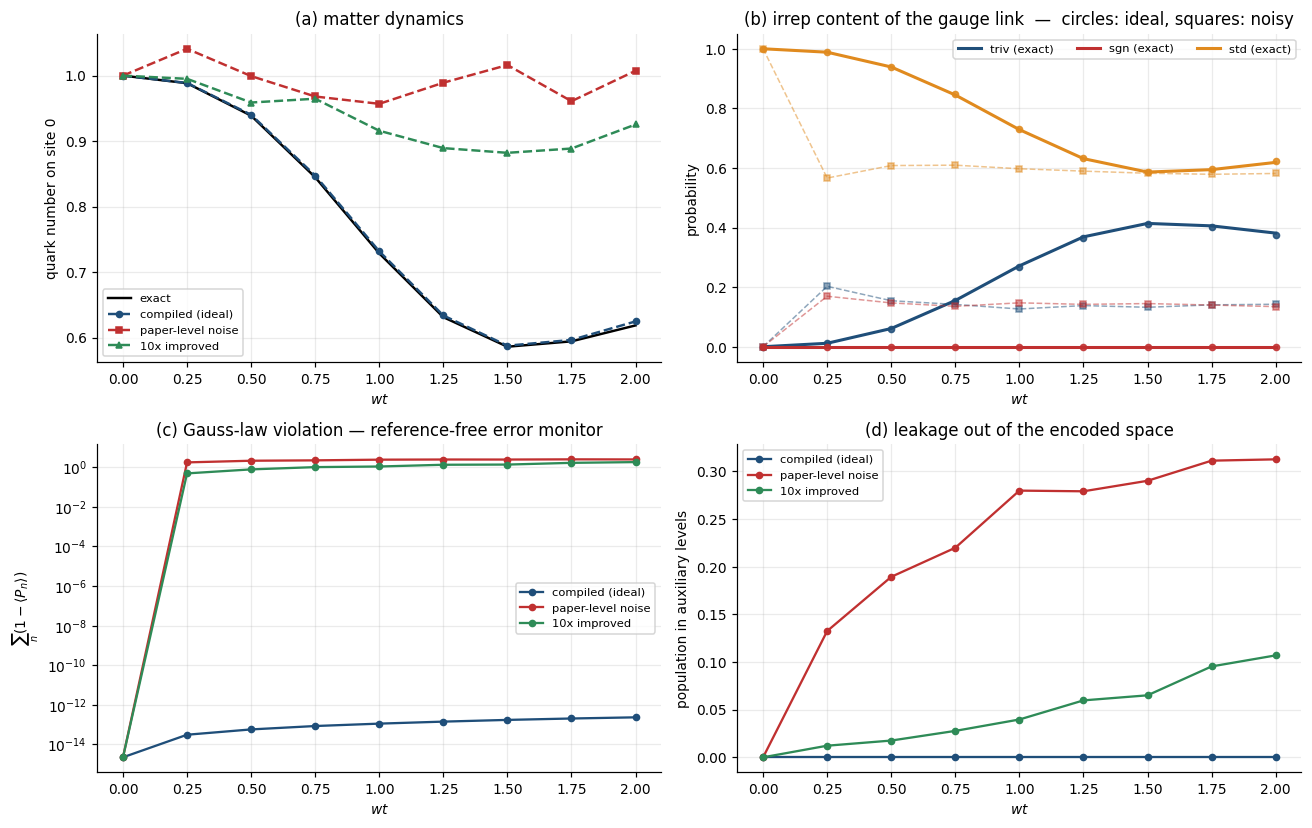

                        N_0 final   Gauss viol.   leakage
exact                      0.6187      3.55e-15  0.00e+00
compiled (ideal)           0.6248      2.32e-13  7.47e-31
paper-level noise          1.0074      2.47e+00  3.13e-01
10x improved               0.9254      1.81e+00  1.07e-01


In [18]:
get = lambda seq, key: np.array([d[key] for d in seq])
fig, ax = plt.subplots(2, 2, figsize=(12, 7.6))
CB = {'exact': 'k', 'ideal': '#1f4e79', 'noisy': '#c03030', 'n10': '#2e8b57'}

# (a) quark motion
for lab, seq, st, c in [('exact', exact, '-', CB['exact']), ('compiled (ideal)', ideal, 'o--', CB['ideal']),
                        ('paper-level noise', noisy, 's--', CB['noisy']),
                        ('10x improved', noisy10, '^--', CB['n10'])]:
    ax[0, 0].plot(tgrid, get(seq, 'N0'), st, ms=4, lw=1.6, color=c, label=lab)
ax[0, 0].set_xlabel('$wt$'); ax[0, 0].set_ylabel(r'quark number on site 0')
ax[0, 0].set_title('(a) matter dynamics'); ax[0, 0].legend(fontsize=7.5)

# (b) NON-ABELIAN FLUX: irrep populations of link 0
for jn, c in zip(JLIST, ['#1f4e79', '#c03030', '#e08a1e']):
    ax[0, 1].plot(tgrid, get(exact, 'P_'+jn), '-', color=c, lw=2, label=f'{jn} (exact)')
    ax[0, 1].plot(tgrid, get(ideal, 'P_'+jn), 'o', color=c, ms=4, alpha=0.85)
    ax[0, 1].plot(tgrid, get(noisy, 'P_'+jn), 's--', color=c, ms=3.5, alpha=0.5, lw=1)
ax[0, 1].set_xlabel('$wt$'); ax[0, 1].set_ylabel('probability')
ax[0, 1].set_title('(b) irrep content of the gauge link  —  circles: ideal, squares: noisy')
ax[0, 1].legend(fontsize=7.5, ncol=3)

# (c) Gauss-law violation
for lab, seq, c in [('compiled (ideal)', ideal, CB['ideal']), ('paper-level noise', noisy, CB['noisy']),
                    ('10x improved', noisy10, CB['n10'])]:
    ax[1, 0].semilogy(tgrid, np.maximum(get(seq, 'gauss'), 1e-17), 'o-', ms=4, color=c, label=lab)
ax[1, 0].set_xlabel('$wt$'); ax[1, 0].set_ylabel(r'$\sum_n (1-\langle P_n\rangle)$')
ax[1, 0].set_title('(c) Gauss-law violation — reference-free error monitor'); ax[1, 0].legend(fontsize=7.5)

# (d) leakage into the auxiliary level
for lab, seq, c in [('compiled (ideal)', ideal, CB['ideal']), ('paper-level noise', noisy, CB['noisy']),
                    ('10x improved', noisy10, CB['n10'])]:
    ax[1, 1].plot(tgrid, get(seq, 'aux'), 'o-', ms=4, color=c, label=lab)
ax[1, 1].set_xlabel('$wt$'); ax[1, 1].set_ylabel('population in auxiliary levels')
ax[1, 1].set_title('(d) leakage out of the encoded space'); ax[1, 1].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

print(f"{'':<22}{'N_0 final':>11}{'Gauss viol.':>14}{'leakage':>10}")
for lab, seq in [('exact', exact), ('compiled (ideal)', ideal),
                 ('paper-level noise', noisy), ('10x improved', noisy10)]:
    print(f"{lab:<22}{get(seq,'N0')[-1]:>11.4f}{get(seq,'gauss')[-1]:>14.2e}{get(seq,'aux')[-1]:>10.2e}")

### Reading the figure

**(a)** The compiled circuit tracks the exact evolution; the small residual is second-order Trotter
error at $\tau=0.25$, exactly as in the abelian case.

**(b) is the panel worth dwelling on, and it has no abelian counterpart.** The gauge link does not
carry a number — it carries a *representation*, and the population moves between the trivial, standard
and sign irreps as the quarks rearrange. Concretely: when the two quarks sit on adjacent sites they are
bound through a link in the **standard** irrep; when they land on the same site the pair is
antisymmetric in colour, sits in the **sign** irrep, and the flux on the link must follow. **Watching
probability flow between irreps is the direct experimental signature that the simulated theory is
non-abelian**, and it is measurable — an irrep-basis measurement is one Peter–Weyl transform followed
by ordinary level detection, which §7 already showed costs a single-qudit gate.

**(c)** The ideal compiled circuit sits at machine precision. This is not luck: $W$ is exactly unitary
and block-diagonal in the group basis, so gauge invariance is preserved **by construction**, not to
Trotter order — the same structural guarantee the $XX{+}YY$ cancellation gave in the abelian model.
Every visible curve is therefore pure hardware error, measurable on a real device without ever
computing the true answer.

**(d)** The auxiliary level is populated only *during* the controlled-rotation gadget and returns to
zero at the end of every gate in the ideal circuit. Under noise it acquires a small steady population
— an independent leakage diagnostic, and a reminder that the $7$th level is a real physical resource
being used, not free bookkeeping.

**The honest headline, and it is not a favourable one.** Eight Trotter steps at $90$ MS gates each is
$720$ entangling gates. At $\varepsilon_{\rm MS}=2.4\%$ the circuit fidelity is
$(0.976)^{720}\approx3\times10^{-8}$, so the run is destroyed several times over: the Gauss monitor
saturates within the first two steps, a quarter of the population ends up in the auxiliary levels, and
the quark number wanders to a value the physical sector does not even contain.

The $10\times$ improvement does **not** rescue it either — $(0.9976)^{720}\approx0.18$, and the
observables confirm it. This circuit is *longer* than the $U(1)$ one analysed in the companion notebook
($720$ versus $336$ MS gates for a comparable window), so if anything the requirement here is stricter:
$\varepsilon_{\rm MS}$ of order $10^{-4}$ — a hundredfold improvement — or a substantially shallower
circuit. Two concrete routes to the latter are visible in the compilation itself and are worth pursuing
before anything else: consecutive $W^\dagger \dots W$ pairs across adjacent bonds and Trotter steps
admit partial cancellation, and a first-order Trotter step would cut the bond applications per step
from three to two at $N=3$. Neither changes the order of magnitude on its own.

---
# 9. Cost accounting, and what this says about scaling up

Three encodings of the same $S_3$ theory are compared:

* **qudit-native** (this notebook): matter $d=4$, link $d=6{+}1$, using the paper's MS primitives.
* **binary qubit**: each $S_3$ link needs $\lceil\log_2 6\rceil=3$ qubits (wasting $2$ of $8$ states,
  which must be projected out), each matter site $2$ qubits. The controlled gate $W$ becomes a
  multiply-controlled operation over $3$ control qubits, and the free hop a set of Pauli-string
  exponentials.
* **the abelian $U(1)$ QLM** from the companion notebook, as a reference point for "what non-abelian
  costs".

  N  qudit MS/step   qubit CNOT/step   ratio  qudit carriers  qubit carriers   U(1) MS/step
  2             30               144    4.80               3               7              4
  3             90               432    4.80               5              12             28
  4            150               720    4.80               7              17             52
  5            210              1008    4.80               9              22             76
  6            270              1296    4.80              11              27            100


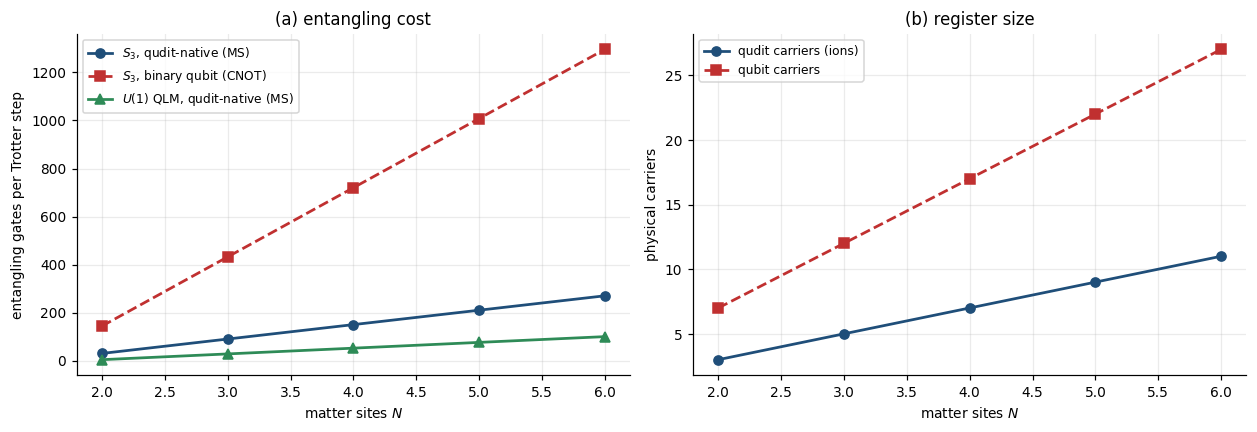


asymptotic entangling-gate saving vs binary qubits : 4.80x
asymptotic carrier saving                         : 2.45x
cost of going non-abelian (S_3 vs U(1), N=3)      : 3.21x more MS gates


In [19]:
def qudit_cost(N):
    per_bond = 2*nms(W_ops()) + nms(hfree_blocks(0.1)[0])
    nb = N - 1
    steps = 2*nb - 1                                  # second-order symmetric ordering
    return per_bond*steps, N + (N-1)                  # (MS per Trotter step, carriers)

def qubit_cost(N):
    '''binary encoding: 3 qubits per link, 2 per matter site.
    W = sum_g |g><g| (x) Theta(g): 6 multiply-controlled 2-qubit gates, each with 3 controls.
    A k-controlled two-qubit gate costs ~ 2(2k-1) CNOTs (standard Barenco-type counting).
    Free hop: 4 Pauli strings of weight 4 -> 2(w-1) = 6 CNOTs each.'''
    k = 3
    W_cx = 6 * 2*(2*k - 1)
    hop_cx = 4 * 6
    per_bond = 2*W_cx + hop_cx
    nb = N - 1
    steps = 2*nb - 1
    return per_bond*steps, 2*N + 3*(N-1)

U1_MS_PER_STEP = {2: 4, 3: 28, 4: 52, 5: 76, 6: 100}   # from the companion notebook

print(f"{'N':>3} {'qudit MS/step':>14} {'qubit CNOT/step':>17} {'ratio':>7} "
      f"{'qudit carriers':>15} {'qubit carriers':>15} {'U(1) MS/step':>14}")
rows = []
for N in (2, 3, 4, 5, 6):
    mms, mc = qudit_cost(N); qcx, qc = qubit_cost(N)
    rows.append((N, mms, qcx, qcx/mms, mc, qc, U1_MS_PER_STEP.get(N)))
    print(f'{N:>3} {mms:>14} {qcx:>17} {qcx/mms:>7.2f} {mc:>15} {qc:>15} '
          f'{str(U1_MS_PER_STEP.get(N)):>14}')

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
Ns = [r[0] for r in rows]
ax[0].plot(Ns, [r[1] for r in rows], 'o-', color='#1f4e79', lw=1.8, label='$S_3$, qudit-native (MS)')
ax[0].plot(Ns, [r[2] for r in rows], 's--', color='#c03030', lw=1.8, label='$S_3$, binary qubit (CNOT)')
ax[0].plot(Ns, [r[6] for r in rows], '^-', color='#2e8b57', lw=1.8, label='$U(1)$ QLM, qudit-native (MS)')
ax[0].set_xlabel('matter sites $N$'); ax[0].set_ylabel('entangling gates per Trotter step')
ax[0].set_title('(a) entangling cost'); ax[0].legend(fontsize=8)

ax[1].plot(Ns, [r[4] for r in rows], 'o-', color='#1f4e79', lw=1.8, label='qudit carriers (ions)')
ax[1].plot(Ns, [r[5] for r in rows], 's--', color='#c03030', lw=1.8, label='qubit carriers')
ax[1].set_xlabel('matter sites $N$'); ax[1].set_ylabel('physical carriers')
ax[1].set_title('(b) register size'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'\nasymptotic entangling-gate saving vs binary qubits : {rows[-1][3]:.2f}x')
print(f'asymptotic carrier saving                         : {rows[-1][5]/rows[-1][4]:.2f}x')
print(f'cost of going non-abelian (S_3 vs U(1), N=3)      : '
      f'{rows[1][1]/U1_MS_PER_STEP[3]:.2f}x more MS gates')

### Reading the output

**Non-abelian costs a factor of a few, not a factor of ten.** At $N=3$ the $S_3$ theory needs about
$3\times$ the entangling gates of the $U(1)$ quantum link model on the same hardware. Given the move
from a one-generator abelian group to a genuinely non-abelian one with a two-dimensional irrep and
non-commuting constraints, that is a mild penalty, and it is worth being clear about *why* it is mild:
the factorisation theorem of §7.1 confined the entire gauge structure to $W$, whose group structure
then collapsed to $7$ MS gates. Without that factorisation the same gate would have cost an order of
magnitude more.

**The qudit advantage is larger here than in the abelian case, and it does not erode with $N$.** In
the $U(1)$ study the entangling-gate advantage over a binary qubit encoding decayed towards $1.1\times$
as the chain grew. Here the ratio sits near $4.8\times$ and stays there. Both encodings are strictly
linear in $N$ with a fixed per-bond cost, so the constancy is a property of the per-bond comparison
rather than an emergent scaling result — but the *size* of that constant is the point, and it has a
clear cause: the binary encoding must implement $W$ as six **multiply-controlled** gates over three
control qubits, and multi-controlled gates are exactly what qudits make cheap. In a qudit the control
is a single level of a single carrier; in a qubit register it is a conjunction that must be
synthesised. The suggestive conclusion is that **the more structure the gauge group carries, the better
the qudit encoding looks**, because the group manifold fits inside one carrier and group elements
become individually addressable levels.

Two caveats. The CNOT counts use standard Barenco-type multi-controlled decompositions without
ancillas; ancilla-assisted constructions would narrow the gap. And the comparison scores one MS gate
against one CNOT, which flatters the qudit side on fidelity grounds while ignoring that the binary
encoding also wastes two of every eight link states and must project them out.

**But the depth is still the binding constraint.** As in the companion notebook, the honest bottom
line is set by $\varepsilon_{\rm MS}$, not by the encoding. Nothing here changes that conclusion.

---

## 9.1 Summary

1. The $S_3$ gauge link is **exactly** a $d=6$ qudit — no truncation anywhere in the model. With one
   auxiliary level for spectroscopic decoupling it uses $7$ of the $8$ available $^{40}$Ca$^+$ levels.
2. Gauss's law becomes a set of **non-commuting unitary constraints**, verified explicitly, with the
   physical projector given by the group average.
3. **The factorisation theorem** $e^{-i\tau H_{\rm bond}} = W^\dagger(\mathbb 1\otimes e^{-i\tau
   h_{\rm free}})W$ is exact and is the central result: the entire non-abelian gauge coupling compiles
   into one controlled gate, and the dynamics reduce to ordinary free-fermion hopping.
4. $W$ costs exactly **7 MS gates** by exploiting $\Theta(s^ar^b)=\Theta(s)^a\Theta(r)^b$ and a level
   ordering chosen to put the colour doublet on an adjacent pair.
5. The compiled circuit is **gauge-invariant by construction**, so $1-\langle P_n\rangle$ is a
   reference-free hardware error monitor, and the auxiliary-level population is a second one.
6. **Irrep populations of the link** are the experimental signature of non-abelian dynamics, and are
   measurable with one Peter–Weyl transform plus ordinary detection.
7. Cost: $30$ MS gates per bond, $\sim3\times$ the abelian $U(1)$ model, with a $\sim4.8\times$
   advantage over a binary qubit encoding that — unlike the abelian case — does not erode with $N$.
8. **But the depth is fatal at present error rates**: $720$ MS gates for the eight-step run of §8 means
   $\varepsilon_{\rm MS}\sim10^{-4}$ is needed, not the $10\times$ improvement the paper projects. This
   is the same conclusion the abelian study reached, only sharper.

## 9.2 Where to go next

* **$D_4$ and $Q_8$** (order 8) are the natural next finite groups: still non-abelian, still exactly
  encodable, and $D_4$ is a standard stepping stone towards $SU(2)$ in the finite-subgroup approach to
  lattice gauge theory. The entire pipeline above transfers with only the group data changed.
* **Two spatial dimensions**, where a plaquette term appears. The plaquette is diagonal in the group
  basis, so it should compile into controlled-phase gates by the same logic that made $U^{\alpha\beta}$
  a control here — worth checking, since it is the first place a finite group buys something a
  continuous one does not.
* **$SU(2)$ proper**, via the rishon/quantum-link representation sketched at the start of this project.
  The factorisation theorem of §7.1 relies only on $U^{\alpha\beta}$ being diagonal in a basis the
  hardware can address, which is *not* true for a continuous group — so the natural question is how
  much of it survives, and that is the right next piece of work.